# 04 — KFold ou GroupKFold par soudure ?

## 1. Objectif

On cherche à savoir si les performances changent lorsque toutes les observations ayant le même
`Weld_ID` restent dans le même pli. Les cinq modèles du notebook 03 sont évalués avec les mêmes
données, le même prétraitement et les mêmes métriques : R², RMSE et MAE.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, KFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
N_SPLITS = 5
TARGETS = ["Yield_strength", "UTS", "Elongation", "Reduction_area", "Charpy_energy"]
UNITS = {
    "Yield_strength": "MPa", "UTS": "MPa", "Elongation": "%",
    "Reduction_area": "%", "Charpy_energy": "J",
}
CAT_COLS = ["AC_DC", "Polarity", "Weld_type"]
ALLOY_COLS = ["Cu_wt", "Mo_wt", "Ni_wt", "Cr_wt", "V_wt"]
DROP_COLS = ["W_wt", "Co_wt"]

SOURCE_COLUMNS = '''C_wt Si_wt Mn_wt S_wt P_wt Ni_wt Cr_wt Mo_wt V_wt Cu_wt Co_wt W_wt
O_ppm Ti_ppm N_ppm Al_ppm B_ppm Nb_ppm Sn_ppm As_ppm Sb_ppm Current_A Voltage_V AC_DC
Polarity Heat_input Interpass_temp Weld_type PWHT_temp PWHT_time Yield_strength UTS Elongation
Reduction_area Charpy_temp Charpy_energy Hardness FATT_50 Primary_ferrite Ferrite_2nd_phase
Acicular_ferrite Martensite Ferrite_carbide Weld_ID'''.split()
BASE_FEATURES = SOURCE_COLUMNS[:30]

def trouver_racine():
    for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (folder / "data" / "welddb.data").is_file():
            return folder
    raise FileNotFoundError("Le fichier data/welddb.data est introuvable.")

PROJECT_ROOT = trouver_racine()
DATA_PATH = PROJECT_ROOT / "data" / "welddb.data"
print("Configuration prête — source locale WeldDB détectée.")

Configuration prête — source locale WeldDB détectée.


## 2. Chargement des données

Les exports du notebook 01 ne conservent pas `Weld_ID`. On recharge donc la source locale, sans
téléchargement, puis on applique le même nettoyage simple que dans les notebooks précédents.

In [2]:
df = pd.read_csv(
    DATA_PATH, sep=r"\s+", header=None, names=SOURCE_COLUMNS,
    dtype=str, na_values=["N"], keep_default_na=True,
)

def convertir_sous_seuil(series):
    text = series.astype("string").str.strip()
    below = text.str.startswith("<", na=False)
    values = pd.to_numeric(
        text.str.replace("<", "", regex=False), errors="coerce"
    ).astype(float)
    return values.where(~below, values / 2)

for column in SOURCE_COLUMNS[:12]:
    df[column] = convertir_sous_seuil(df[column])

for column in SOURCE_COLUMNS[12:21]:
    df[column] = convertir_sous_seuil(df[column]).fillna(0.0)

for column in CAT_COLS:
    df[column] = df[column].fillna("Unknown").astype(str).str.strip()
df["Weld_type"] = df["Weld_type"].replace({"ShMA": "MMA", "SMA": "SA"})

numeric_columns = [
    column for column in BASE_FEATURES + ["Charpy_temp"] + TARGETS
    if column not in CAT_COLS and column not in SOURCE_COLUMNS[:21]
]
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column].astype("string").str.replace("<", "", regex=False), errors="coerce"
    )
df[["PWHT_temp", "PWHT_time"]] = df[["PWHT_temp", "PWHT_time"]].fillna(0.0)

print(f"Données chargées : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
display(pd.DataFrame({
    "cible": TARGETS,
    "observations disponibles": [df[target].notna().sum() for target in TARGETS],
    "unité": [UNITS[target] for target in TARGETS],
}))

Données chargées : 1652 lignes et 44 colonnes.


,cible,observations disponibles,unité
0,Yield_strength,780,MPa
1,UTS,738,MPa
2,Elongation,700,%
3,Reduction_area,705,%
4,Charpy_energy,879,J


## 3. Construction des groupes `Weld_ID`

`Weld_ID` sert uniquement à former les groupes. Il n'est jamais fourni aux modèles.

In [3]:
datasets = {}
group_rows = []

for target in TARGETS:
    feature_columns = BASE_FEATURES + (["Charpy_temp"] if target == "Charpy_energy" else [])
    valid = df[target].notna()

    X = df.loc[valid, feature_columns].copy()
    X["PWHT_done"] = (X["PWHT_temp"] > 0).astype(float)
    X = X.drop(columns=DROP_COLS).reset_index(drop=True)
    y = df.loc[valid, target].astype(float).reset_index(drop=True)
    groups = df.loc[valid, "Weld_ID"].astype(str).reset_index(drop=True)

    assert "Weld_ID" not in X.columns and target not in X.columns
    assert groups.nunique() >= N_SPLITS
    datasets[target] = {"X": X, "y": y, "groups": groups}

    sizes = groups.value_counts()
    group_rows.append({
        "cible": target,
        "observations": len(y),
        "Weld_ID distincts": groups.nunique(),
        "groupes répétés": int((sizes > 1).sum()),
        "observations dans un groupe répété": int(sizes[sizes > 1].sum()),
    })

group_summary = pd.DataFrame(group_rows)
display(group_summary)

,cible,observations,Weld_ID distincts,groupes répétés,observations dans un groupe répété
0,Yield_strength,780,743,35,72
1,UTS,738,697,39,80
2,Elongation,700,668,30,62
3,Reduction_area,705,667,36,74
4,Charpy_energy,879,809,31,101


## 4. Validation KFold

KFold répartit aléatoirement les lignes en cinq plis. Le prétraitement reste appris uniquement sur la
partie entraînement de chaque pli.

In [4]:
def make_preprocessor(columns):
    ppm_cols = [column for column in columns if column.endswith("_ppm")]
    alloy_cols = [column for column in ALLOY_COLS if column in columns]
    cat_cols = [column for column in CAT_COLS if column in columns]
    other_cols = [
        column for column in columns
        if column not in ppm_cols + alloy_cols + cat_cols
    ]

    return ColumnTransformer([
        ("ppm", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=0.0, keep_empty_features=True)),
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]), ppm_cols),
        ("alloy", Pipeline([
            ("impute", SimpleImputer(
                strategy="constant", fill_value=0.0,
                add_indicator=True, keep_empty_features=True,
            )),
            ("scale", StandardScaler()),
        ]), alloy_cols),
        ("other", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), other_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ])

MODELS = {
    "Baseline (médiane)": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=10.0),
    "kNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

def make_pipeline(model, columns):
    return Pipeline([
        ("prep", make_preprocessor(columns)),
        ("model", clone(model)),
    ])

print("Modèles comparés :", ", ".join(MODELS))

Modèles comparés : Baseline (médiane), Ridge, kNN, Random Forest, Gradient Boosting


In [5]:
SCORING = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

def evaluer(protocol):
    rows = []
    for target, data in datasets.items():
        X, y, groups = data["X"], data["y"], data["groups"]

        if protocol == "KFold":
            splits = list(KFold(
                n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
            ).split(X, y))
        else:
            splits = list(GroupKFold(n_splits=N_SPLITS).split(X, y, groups=groups))
            for train_idx, valid_idx in splits:
                assert set(groups.iloc[train_idx]).isdisjoint(groups.iloc[valid_idx])

        for model_name, model in MODELS.items():
            scores = cross_validate(
                make_pipeline(model, list(X.columns)), X, y,
                cv=splits, scoring=SCORING, error_score="raise",
            )
            rows.append({
                "cible": target,
                "modèle": model_name,
                "R²": scores["test_r2"].mean(),
                "RMSE": -scores["test_rmse"].mean(),
                "MAE": -scores["test_mae"].mean(),
            })
    return pd.DataFrame(rows)

results_kfold = evaluer("KFold")
print(f"KFold terminé : {len(results_kfold)} combinaisons cible-modèle.")

KFold terminé : 25 combinaisons cible-modèle.


## 5. Validation GroupKFold

GroupKFold utilise aussi cinq plis, mais un même `Weld_ID` ne peut pas apparaître à la fois dans
l'entraînement et la validation.

In [6]:
results_group = evaluer("GroupKFold")
print(f"GroupKFold terminé : {len(results_group)} combinaisons cible-modèle.")
print("Vérification réussie : aucun Weld_ID ne traverse un pli.")

GroupKFold terminé : 25 combinaisons cible-modèle.
Vérification réussie : aucun Weld_ID ne traverse un pli.


## 6. Comparaison des résultats

Les deux protocoles portent sur les mêmes observations. Un écart de R² proche de zéro indique des
performances similaires ; RMSE et MAE gardent l'unité de la cible.

In [7]:
comparison = results_kfold.merge(
    results_group, on=["cible", "modèle"], suffixes=("_KFold", "_GroupKFold")
)
comparison["ΔR²"] = comparison["R²_GroupKFold"] - comparison["R²_KFold"]
comparison["unité"] = comparison["cible"].map(UNITS)

comparison_table = comparison.rename(columns={
    "cible": "Cible", "modèle": "Modèle",
    "R²_KFold": "R² KFold", "R²_GroupKFold": "R² GroupKFold",
    "RMSE_KFold": "RMSE KFold", "RMSE_GroupKFold": "RMSE GroupKFold",
    "MAE_KFold": "MAE KFold", "MAE_GroupKFold": "MAE GroupKFold",
    "unité": "Unité",
})[[
    "Cible", "Modèle", "Unité", "R² KFold", "R² GroupKFold", "ΔR²",
    "RMSE KFold", "RMSE GroupKFold", "MAE KFold", "MAE GroupKFold",
]]
display(comparison_table.round(3))

,Cible,Modèle,Unité,R² KFold,R² GroupKFold,ΔR²,RMSE KFold,RMSE GroupKFold,MAE KFold,MAE GroupKFold
0,Yield_strength,Baseline (médiane),MPa,-0.024,-0.024,0.000,93.273,93.749,71.087,70.983
1,Yield_strength,Ridge,MPa,0.487,0.540,0.053,65.194,62.689,47.487,46.005
2,Yield_strength,kNN,MPa,0.664,0.697,0.034,52.604,50.845,36.857,36.146
3,Yield_strength,Random Forest,MPa,0.790,0.795,0.004,42.077,41.731,29.760,29.253
4,Yield_strength,Gradient Boosting,MPa,0.808,0.812,0.004,40.301,40.054,28.969,28.726
5,UTS,Baseline (médiane),MPa,-0.059,-0.051,0.008,90.258,90.574,68.404,68.371
6,UTS,Ridge,MPa,0.664,0.688,0.024,50.501,49.224,37.214,36.027
7,UTS,kNN,MPa,0.728,0.749,0.020,45.184,44.022,30.295,30.248
8,UTS,Random Forest,MPa,0.839,0.848,0.009,34.788,34.245,23.808,23.068
9,UTS,Gradient Boosting,MPa,0.840,0.865,0.024,34.368,32.317,23.956,22.599


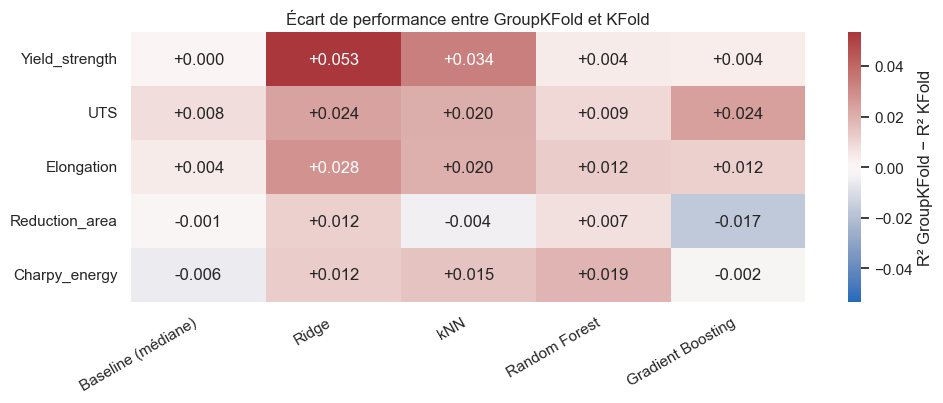

In [8]:
delta_matrix = comparison.pivot(index="cible", columns="modèle", values="ΔR²")
delta_matrix = delta_matrix.loc[TARGETS, list(MODELS)]
limit = max(0.02, float(np.abs(delta_matrix.to_numpy()).max()))

plt.figure(figsize=(10, 4.2))
sns.heatmap(
    delta_matrix, annot=True, fmt="+.3f", cmap="vlag", center=0,
    vmin=-limit, vmax=limit, cbar_kws={"label": "R² GroupKFold − R² KFold"},
)
plt.xlabel("")
plt.ylabel("")
plt.title("Écart de performance entre GroupKFold et KFold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Conclusion

In [9]:
delta_r2 = comparison["ΔR²"]
absolute_gaps = delta_r2.abs()
lower_count = int((delta_r2 < 0).sum())
higher_count = int((delta_r2 > 0).sum())
median_gap = absolute_gaps.median()
largest_gap = absolute_gaps.max()

display(Markdown(
    f"Sur les **{len(comparison)} comparaisons cible-modèle**, GroupKFold donne un R² inférieur "
    f"dans **{lower_count} cas** et supérieur dans **{higher_count} cas**. "
    f"L'écart absolu médian de R² est **{median_gap:.3f}** et le maximum **{largest_gap:.3f}**. "
    "Les performances restent donc globalement proches entre les deux validations."
))

Sur les **25 comparaisons cible-modèle**, GroupKFold donne un R² inférieur dans **5 cas** et supérieur dans **20 cas**. L'écart absolu médian de R² est **0.012** et le maximum **0.053**. Les performances restent donc globalement proches entre les deux validations.